In [1]:
from contextlib import suppress
from nanover.recording import NanoverRecordingReader
from nanover.trajectory import MissingDataError
import re

def read_recording(path):
    health_key = None
    data = []

    with NanoverRecordingReader.from_path(path) as reader:
        for entry, change in reader.iter_state_updates():
            for key in change.updates:
                if "report.connection.health" in key:
                    health_key = key

        for event in reader.iter_max():
            if event.next_state_event is not None:
                with suppress(MissingDataError):
                    data.append({ "particles": event.next_frame.particle_count, "timestamp": event.timestamp, **event.next_state.get(health_key) })

    print(len(data), "x", health_key)
    return data

def read_recording_light(path):
    health_key = None
    data = []

    with NanoverRecordingReader.from_path(path) as reader:
        for entry, change in reader.iter_state_updates():
            for key in change.updates:
                if "report.connection.health" in key:
                    health_key = key

        assert health_key is not None, "No health reports found"
        assert "suggested" not in health_key, "No health reports found"

        for event in reader.iter_max():
            if event.next_state_event is not None:
                with suppress(MissingDataError):
                    count = int(re.search('0*([0-9]+)', event.next_state.get("simulation.name"), re.IGNORECASE).group(1))
                    health = event.next_state.get(health_key)
                    data.append({ "particles": count, "timestamp": event.timestamp, **health })

    print(len(data), "x", health_key)
    return data

In [2]:
DATASETS_REDO = [
    # (read_recording("REDO--solvent-hidden-1-user.nanover.zip"), "1 user"),
    # (read_recording("REDO--solvent-hidden-2-user.nanover.zip"), "2 user"),
    # (read_recording("REDO--solvent-hidden-3-user.nanover.zip"), "3 user"),
    # (read_recording("REDO--solvent-hidden-4-user.nanover.zip"), "4 user"),
    # (read_recording("REDO--solvent-hidden-4-user--granular.nanover.zip"), "4 user"),
]

In [5]:
DATASETS_LIGHT = [
    # (read_recording_light("LAB-310s--solvent-hidden-1-user.nanover.zip"), "1 user nearby"),
    # (read_recording_light("LAB-310s--solvent-hidden-2-user.nanover.zip"), "2 users nearby"),
    # (read_recording_light("LAB-310s--solvent-hidden-3-user.nanover.zip"), "3 users nearby"),
    # (read_recording_light("LAB-310s--solvent-hidden-4-user.nanover.zip"), "4 users nearby"),
    # (read_recording_light("LAB-310s--solvent-hidden-3-user--EXTRA.nanover.zip"), "3 user nearby"),
    # (read_recording_light("HOTSPOT--solvent-hidden-1-user--2026-04-08T-16_26_15.nanover.zip"), "1 user hotspot"),
    # (read_recording_light("5m30s--HOTSPOT--1-user--2026-04-30T-12_41_49.nanover.zip"), "1 user hotspot"),
    (read_recording_light("5m30s--WIFI-ETH--1-user--2026-05-04T-13_13_46.nanover.zip"), "1 user wifi+eth"),
    (read_recording_light("5m30s--WIFI-ETH--2-user--2026-05-04T-12_28_19.nanover.zip"), "2 users wifi+eth"),
    (read_recording_light("5m30s--WIFI-ETH--3-user--2026-05-04T-11_40_57.nanover.zip"), "3 users wifi+eth"),
    (read_recording_light("5m30s--WIFI-ETH--4-user--2026-04-30T-11_41_12.nanover.zip"), "4 users wifi+eth"),
    (read_recording_light("60s--LOCAL--1-user--2026-05-06T-16_08_09.nanover.zip"), "1 user local"),
]

54796 x report.connection.health.5f224f64-63a3-4b39-9ddb-1912e5a416a9
69299 x report.connection.health.e4a886cd-c3fc-43d6-9735-ac1a6c09454c
68820 x report.connection.health.ffe9f7d0-0c16-464a-a41b-00260a68615d
69304 x report.connection.health.e4e1819a-38db-4c5a-bdab-14e048d9b41a
1505 x report.connection.health.89b15781-76e9-4d9b-8039-55384462082d


(0.0, 35.0)

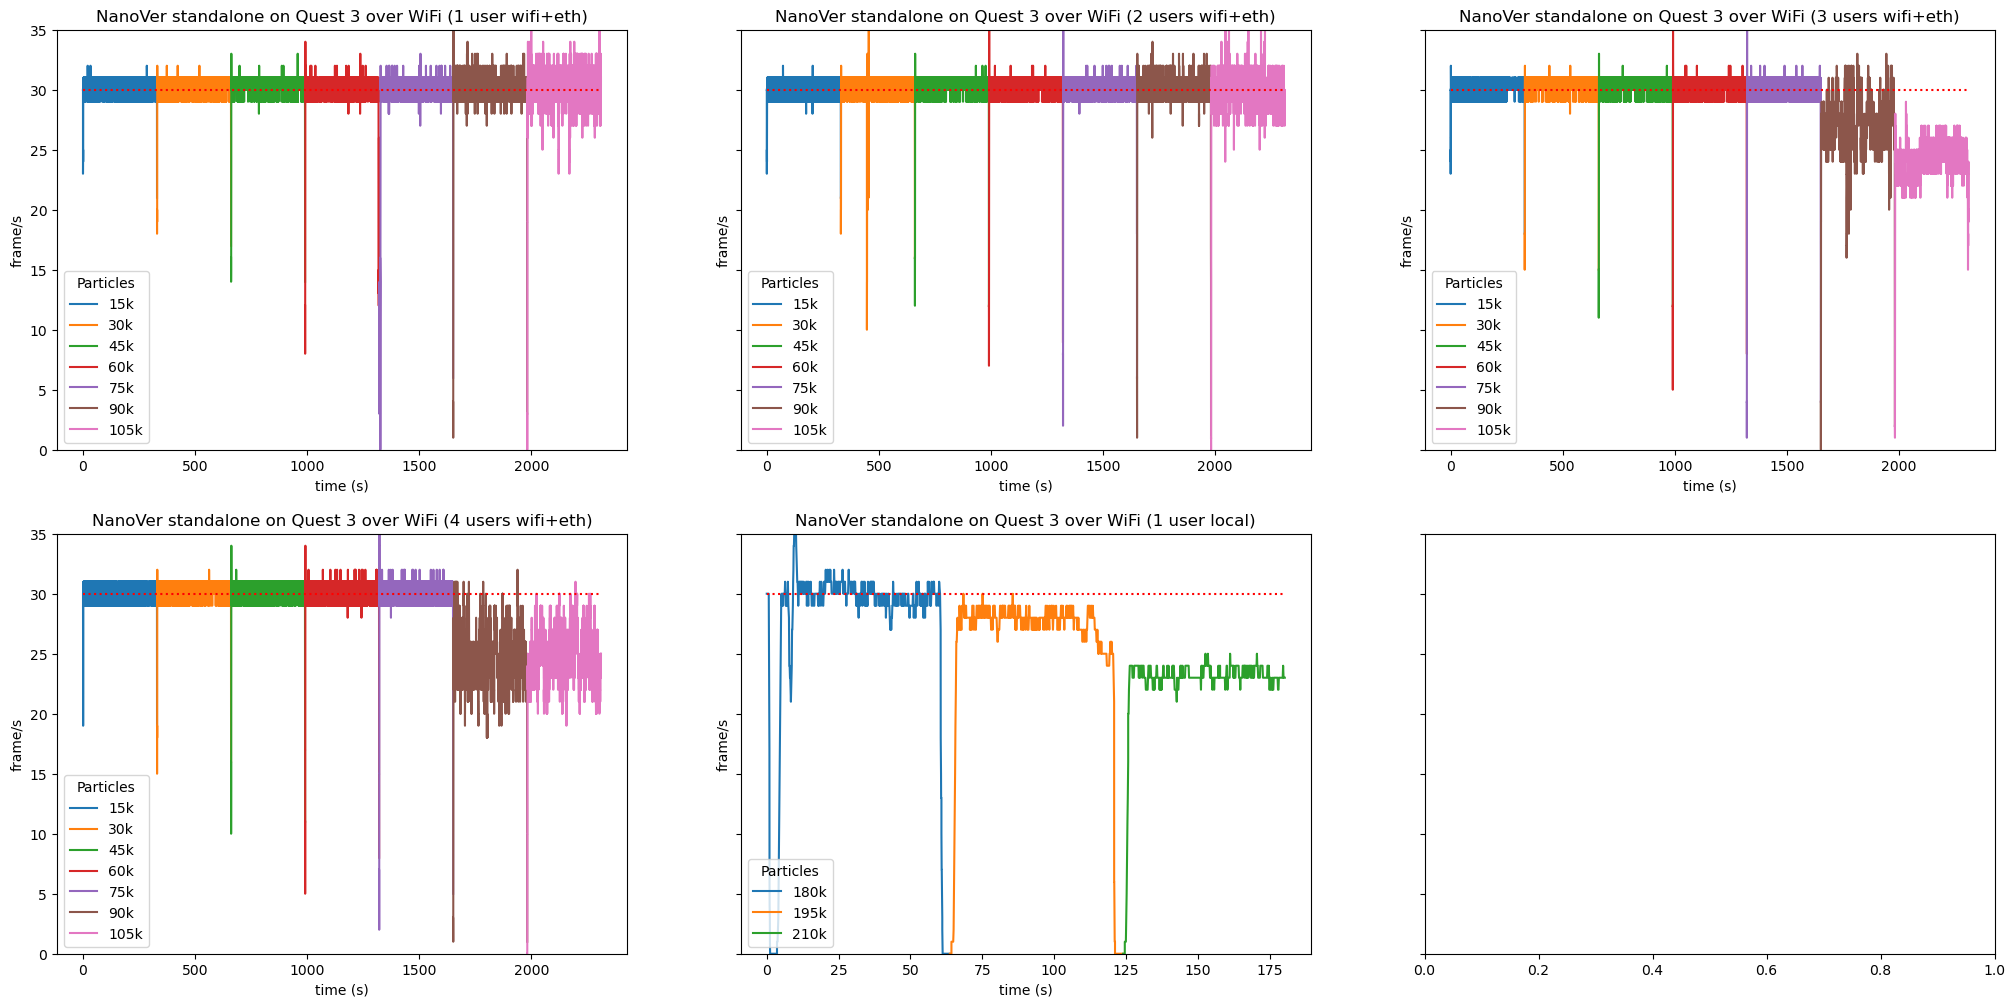

In [6]:
import matplotlib.pyplot as plt
import numpy as np

f, axes = plt.subplots(2, 3, sharey=True)
f.set_figwidth(25)
f.set_figheight(12)

for i, (DATASET, LABEL) in enumerate(DATASETS_LIGHT):
    COUNTS = sorted(set(line["particles"] for line in DATASET))

    ax = axes.flatten()[i]
    ax.set_xlabel("time (s)")
    ax.set_ylabel("frame/s")

    for count in COUNTS:
        DATA = [[line["timestamp"] / 10**6, line["frame"]] for line in DATASET if line["particles"] == count]
        # third = len(DATA) // 3
        # sixth = len(DATA) // 6
        # DATA_X, DATA_Y = [pair[0] for pair in DATA][third:-sixth], [pair[1] for pair in DATA][third:-sixth]
        DATA_X, DATA_Y = [pair[0] for pair in DATA], [pair[1] for pair in DATA]
        ax.plot(DATA_X, DATA_Y, label=f"{count//1000}k")

    ax.legend(title="Particles", loc="lower left")
    ax.title.set_text(f"NanoVer standalone on Quest 3 over WiFi ({LABEL})")
    ax.hlines(30, 0, max(DATA_X), color="red", linestyles="dotted")
    # ax.set_xticks([x*300+30 for x in range(len(DATASETS_LIGHT)+2)])
    ax.legend(title="Particles", loc="lower left")

plt.ylim(top=35, bottom=0)
# plt.ylim(top=250)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

f, axes = plt.subplots(2, 3, sharey=True)
f.set_figwidth(25)
f.set_figheight(12)

for i, (DATASET, LABEL) in enumerate(DATASETS_LIGHT):
    COUNTS = sorted(set(line["particles"] for line in DATASET))

    ax = axes.flatten()[i]
    ax.set_xlabel("time (s)")
    ax.set_ylabel("rtt (ms)")

    for count in COUNTS:
        DATA = [[line["timestamp"] / 10**6, line["rtt"]] for line in DATASET if line["particles"] == count]
        # third = len(DATA) // 3
        # sixth = len(DATA) // 6
        # DATA_X, DATA_Y = [pair[0] for pair in DATA][third:-sixth], [pair[1] for pair in DATA][third:-sixth]
        DATA_X, DATA_Y = [pair[0] for pair in DATA], [pair[1] for pair in DATA]
        ax.plot(DATA_X, DATA_Y, label=f"{count//1000}k")

    ax.title.set_text(f"NanoVer standalone on Quest 3 over WiFi ({LABEL})")
    # ax.hlines(30, 0, max(DATA_X), color="red", linestyles="dotted")
    # ax.set_xticks([x*300 for x in range(len(DATASETS_LIGHT)+2)])
    ax.legend(title="Particles", loc="upper left")


plt.ylim(top=2000, bottom=0)
# plt.ylim(top=250)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

f, axes = plt.subplots(2, 3, sharey=True)
f.set_figwidth(25)
f.set_figheight(12)

for i, (DATASET, LABEL) in enumerate(DATASETS_REDO):
    COUNTS = sorted(set(line["particles"] for line in DATASET))

    ax = axes.flatten()[i]
    ax.set_xlabel("rtt (ms)")
    ax.set_ylabel("count")

    for count in COUNTS:
        DATA = [[line["timestamp"] / 10**6, line["rtt"]] for line in DATASET if line["particles"] == count]
        third = len(DATA) // 3
        sixth = len(DATA) // 6
        DATA_X, DATA_Y = [pair[0] for pair in DATA][third:-sixth], [pair[1] for pair in DATA][third:-sixth]
        # ax.plot(DATA_X, DATA_Y, label=f"{count//1000}k")

        # counts, bins = np.histogram(DATA_Y)
        ax.hist(DATA_Y, bins=[25*i for i in range(40)], label=f"{count//1000}k", histtype='step')

    ax.legend(title="Particles", loc="upper right")
    ax.title.set_text(f"NanoVer standalone on Quest 3 over WiFi ({LABEL})")
    # # ax.hlines(30, 0, max(DATA_X), color="red", linestyles="dotted")
    # ax.set_xticks([x*30 for x in range(len(DATASETS)+2)])
    # ax.legend(title="Particles", loc="lower left")

# plt.ylim(top=2000, bottom=0)
# plt.ylim(top=250)

In [ ]:
import matplotlib.pyplot as plt

f, axes = plt.subplots(6, 1, sharey=True)
f.set_figwidth(10)
f.set_figheight(40)

for i, (DATASET, LABEL) in enumerate(DATASETS_LIGHT):
    COUNTS = sorted(set(line["particles"] for line in DATASET))

    ax = axes.flatten()[i]
    ax.title.set_text(f"NanoVer standalone on Quest 3 over WiFi ({LABEL})")
    ax.set_xlabel("particles")
    ax.set_ylabel("rtt (ms)")

    DATAS = []
    LABELS = []

    for count in COUNTS:
        DATA = [[line["timestamp"] / 10**6, line["rtt"]] for line in DATASET if line["particles"] == count]
        # third = len(DATA) // 3
        # sixth = len(DATA) // 6
        # DATA_X, DATA_Y = [pair[0] for pair in DATA][third:-sixth], [pair[1] for pair in DATA][third:-sixth]
        DATA_X, DATA_Y = [pair[0] for pair in DATA], [pair[1] for pair in DATA]
        DATAS.append(DATA_Y)
        LABELS.append(f"{count//1000}k")

    ax.boxplot(DATAS, orientation="vertical", tick_labels=LABELS)
    ax.axhline(200, 0, 1, color="red", linestyle="dotted")

plt.ylim(top=500, bottom=0)

In [ ]:
import matplotlib.pyplot as plt

f, axes = plt.subplots(1, sharey=True)
f.set_figwidth(15)
f.set_figheight(5)

ax = axes
ax.title.set_text(f"NanoVer standalone on Quest 3 over WiFi (4 users)")
ax.set_xlabel("particles")
ax.set_ylabel("rtt (ms)")

DATAS = []
LABELS = []

DATASET = DATASETS_REDO[4][0]
COUNTS = sorted(set(line["particles"] for line in DATASET))
for count in COUNTS:
    DATA = [[line["timestamp"] / 10**6, line["rtt"]] for line in DATASET if line["particles"] == count]
    third = len(DATA) // 3
    sixth = len(DATA) // 6
    DATA_X, DATA_Y = [pair[0] for pair in DATA][third:-sixth], [pair[1] for pair in DATA][third:-sixth]
    DATAS.append(DATA_Y)
    LABELS.append(f"{count//1000}k")

DATASET = DATASETS_REDO[3][0]
COUNTS = sorted(set(line["particles"] for line in DATASET))[2:]
for count in COUNTS:
    DATA = [[line["timestamp"] / 10**6, line["rtt"]] for line in DATASET if line["particles"] == count]
    third = len(DATA) // 3
    sixth = len(DATA) // 6
    DATA_X, DATA_Y = [pair[0] for pair in DATA][third:-sixth], [pair[1] for pair in DATA][third:-sixth]
    DATAS.append(DATA_Y)
    LABELS.append(f"{count//1000}k")

ax.boxplot(DATAS, orientation="vertical", tick_labels=LABELS)
ax.axhline(200, 0, 1, color="red", linestyle="dotted")

plt.ylim(top=1500, bottom=0)

In [ ]:
import matplotlib.pyplot as plt

f, axes = plt.subplots(2, 3, sharey=True)
f.set_figwidth(25)
f.set_figheight(12)

for i, (DATASET, LABEL) in enumerate(DATASETS_REDO):
    COUNTS = sorted(set(line["particles"] for line in DATASET))

    ax = axes.flatten()[i]
    ax.title.set_text(f"NanoVer standalone on Quest 3 over WiFi ({LABEL})")
    ax.set_xlabel("particles")
    ax.set_ylabel("updates per second")

    DATAS = []
    LABELS = []

    for count in COUNTS:
        DATA = [[line["timestamp"] / 10**6, line["frame"]] for line in DATASET if line["particles"] == count]
        third = len(DATA) // 3
        sixth = len(DATA) // 6
        DATA_X, DATA_Y = [pair[0] for pair in DATA][third:-sixth], [pair[1] for pair in DATA][third:-sixth]
        DATAS.append(DATA_Y)
        LABELS.append(f"{count//1000}k")

    ax.boxplot(DATAS, orientation="vertical", tick_labels=LABELS)
    ax.axhline(30, 0, 1, color="red", linestyle="dotted")

plt.ylim(top=35, bottom=0)

In [ ]:
import matplotlib.pyplot as plt

f, axes = plt.subplots(1, 3, sharey=True)
f.set_figwidth(20)

DATASETS = [
    # (SOLVENT_VISIBLE_1_USER_APK_FPS_GRANULAR, "APK"),
    # (SOLVENT_VISIBLE_1_USER_APK_FPS, "APK"),
    # (SOLVENT_VISIBLE_1_USER_PC_FPS_GRANULAR, "PC-VR Luis' Laptop"),
    # (read_recording_light("30s--rendering--2026-04-22T-11_04_11.nanover.zip"), "DESKTOP"),
    # (read_recording_light("30s--rendering--2026-04-22T-11_38_13--OUTSIDE.nanover.zip"), "OUTSIDE"),
    # (read_recording_light("30s--rendering--2026-04-22T-11_45_21--INSIDE.nanover.zip"), "INSIDE"),
    # (read_recording_light("5m20s--rendering--2026-04-24T-14_34_37--DESKTOP.nanover.zip"), "DESKTOP LONG"),
    # (read_recording_light("5m20s--rendering--2026-04-27T-12_07_24--DESKTOP.nanover.zip"), "DESKTOP LONG"),
    # (read_recording_light("5m20s--rendering--2026-04-24T-15_24_09--OUTSIDE.nanover.zip"), "OUTSIDE LONG"),
    # (read_recording_light("5m20s--rendering--2026-04-27T-12_43_24--OUTSIDE.nanover.zip"), "OUTSIDE LONG"),
    # (read_recording_light("5m20s--rendering--2026-04-24T-16_57_52--INSIDE.nanover.zip"), "INSIDE LONG"),
    # (read_recording_light("5m20s--rendering--2026-04-27T-12_25_35--INSIDE.nanover.zip"), "INSIDE LONG"),
    # (read_recording_light("40s--rendering--2026-04-27T-13_39_03--DESKTOP-PC-VR-AIR.nanover.zip"), "PC-VR AIR DESKTOP"),
    (read_recording_light("5m30s--rendering--2026-04-27T-13_51_58--DESKTOP-PC-VR.nanover.zip"), "PC-VR DESKTOP LONG"),
    (read_recording_light("5m30s--rendering--2026-04-28T-13_11_54--OUTSIDE-PC-VR.nanover.zip"), "PC-VR OUTSIDE LONG"),
    (read_recording_light("5m30s--rendering--2026-04-28T-17_54_51--INSIDE-PC-VR.nanover.zip"), "PC-VR INSIDE LONG"),
]

FPS_TICKS = [72, 60, 48, 36, 24, 12, 0]

for i, (DATASET, LABEL) in enumerate(DATASETS):
    COUNTS = sorted(set(line["particles"] for line in DATASET))

    ax = axes[i]
    ax.set_xlabel("time (s)")
    ax.set_ylabel("render fps")

    for count in COUNTS:
        DATA = [[line["timestamp"]/ 10**6, line["fps"]] for line in DATASET if line["particles"] == count]
        DATA_X, DATA_Y = [pair[0] for pair in DATA], [min(pair[1], 720) for pair in DATA]
        ax.plot(DATA_X, DATA_Y, label=f"{count/1000}k")

    ax.set_yticks(FPS_TICKS)
    ax.legend(title="Particles", loc="lower left")
    ax.title.set_text(f"NanoVer rendering performance ({LABEL})")
    ax.hlines(72, 0, max(DATA_X), color="red", linestyles="dotted")
    ax.hlines(36, 0, max(DATA_X), color="red", linestyles="dotted")
    # ax.set_xticks([])

plt.ylim(top=72, bottom=0)

In [ ]:
import matplotlib.pyplot as plt

f, axes = plt.subplots(3, 1)
f.set_figwidth(15)
f.set_figheight(20)


SOLVENT_HIDDEN_1_USER_APK_FPS_DESKTOP = read_recording("solvent-visible-1-user--apk--desktop.nanover.zip")
SOLVENT_HIDDEN_1_USER_APK_FPS_OUTSIDE = read_recording("solvent-visible-1-user--apk--outside.nanover.zip")
SOLVENT_HIDDEN_1_USER_APK_FPS_INSIDE = read_recording("solvent-visible-1-user--apk--inside.nanover.zip")

DATASETS = [
    (SOLVENT_HIDDEN_1_USER_APK_FPS_DESKTOP, "DESKTOP"),
    (SOLVENT_HIDDEN_1_USER_APK_FPS_OUTSIDE, "OUTSIDE"),
    (SOLVENT_HIDDEN_1_USER_APK_FPS_INSIDE, "INSIDE"),
]

FPS_TICKS = [72, 60, 48, 36, 24, 12, 0]

for i, (DATASET, LABEL) in enumerate(DATASETS):
    COUNTS = sorted(set(line["particles"] for line in DATASET))

    ax = axes[i]
    ax.set_xlabel("time (s)")
    ax.set_ylabel("fps")
    ax.grid(axis="y")

    ax.set_xlim(left=0, right=320)
    ax.set_ylim(top=75, bottom=0)

    for count in COUNTS:
        DATA = [[line["timestamp"]/ 10**6, line["fps"]] for line in DATASET if line["particles"] == count]
        DATA_X, DATA_Y = [pair[0] for pair in DATA], [pair[1] for pair in DATA]

        ax.plot(DATA_X, DATA_Y, label=f"{count/1000}k")

    if (i == 0):
        ax.legend(title="Particles", loc="lower left")
    ax.title.set_text(f"NanoVer rendering performance ({LABEL})")
    # for fps in FPS_TICKS:
    #     ax.hlines(fps, 0, max(DATA_X), color="red", linestyles="dotted")
    ax.set_xticks([x*20 for x in range(17)])
    ax.set_yticks(FPS_TICKS)


In [ ]:
import matplotlib.pyplot as plt

f, axes = plt.subplots(3, 1)
f.set_figwidth(15)
f.set_figheight(20)


SOLVENT_HIDDEN_1_USER_APK_FPS_DESKTOP = read_recording("solvent-visible-1-user--apk--desktop.nanover.zip")
SOLVENT_HIDDEN_1_USER_APK_FPS_OUTSIDE = read_recording("REDO--solvent-visible-1-user--apk--outside.nanover.zip")
SOLVENT_HIDDEN_1_USER_APK_FPS_INSIDE = read_recording("solvent-visible-1-user--apk--inside.nanover.zip")

DATASETS = [
    (SOLVENT_HIDDEN_1_USER_APK_FPS_DESKTOP, "DESKTOP"),
    (SOLVENT_HIDDEN_1_USER_APK_FPS_OUTSIDE, "OUTSIDE"),
    (SOLVENT_HIDDEN_1_USER_APK_FPS_INSIDE, "INSIDE"),
]

FPS_TICKS = [72, 60, 48, 36, 24, 12, 0]

for i, (DATASET, LABEL) in enumerate(DATASETS):
    COUNTS = sorted(set(line["particles"] for line in DATASET))

    ax = axes[i]
    ax.set_xlabel("time (s)")
    ax.set_ylabel("fps")
    ax.grid(axis="y")

    ax.set_xlim(left=0, right=320)
    ax.set_ylim(top=75, bottom=0)

    for count in COUNTS:
        DATA = [[line["timestamp"]/ 10**6, line["fps"]] for line in DATASET if line["particles"] == count]
        DATA_X, DATA_Y = [pair[0] for pair in DATA], [pair[1] for pair in DATA]

        ax.plot(DATA_X, DATA_Y, label=f"{count/1000}k")

    if (i == 0):
        ax.legend(title="Particles", loc="lower left")
    ax.title.set_text(f"NanoVer rendering performance ({LABEL})")
    # for fps in FPS_TICKS:
    #     ax.hlines(fps, 0, max(DATA_X), color="red", linestyles="dotted")
    ax.set_xticks([x*20 for x in range(17)])
    ax.set_yticks(FPS_TICKS)
